# 06 Model Interpretation

Use averaged feature importance across CV folds and best-fold SHAP plots for LightGBM and XGBoost.

In [18]:
from pathlib import Path
import sys

import lightgbm as lgb
import pandas as pd
import xgboost as xgb
from IPython.display import Image, display

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(PROJECT_ROOT / "src"))

from amex_default.config import MODEL_DIR, PLOTS_DIR, REPORTS_DIR
from amex_default.data import load_train_features, split_features_target
from amex_default.interpret import save_best_fold_shap_plots


In [19]:
df = load_train_features()
X, y = split_features_target(df)
print(f"Rows: {len(df):,}; features: {X.shape[1]:,}")


Rows: 229,456; features: 3,418


In [20]:
def best_fold_from_report(model_name):
    metrics = pd.read_json(REPORTS_DIR / f"{model_name}_metrics.json", typ="series")
    fold_metrics = metrics.get("fold_metrics")
    if not fold_metrics:
        raise ValueError(f"No fold metrics found for {model_name}. Rerun its training notebook first.")
    return max(fold_metrics, key=lambda row: row["roc_auc"])["fold"]

/Users/komalpreet/miniconda3/envs/inflection/lib/python3.11/site-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


Saved LightGBM SHAP plots from fold 3.


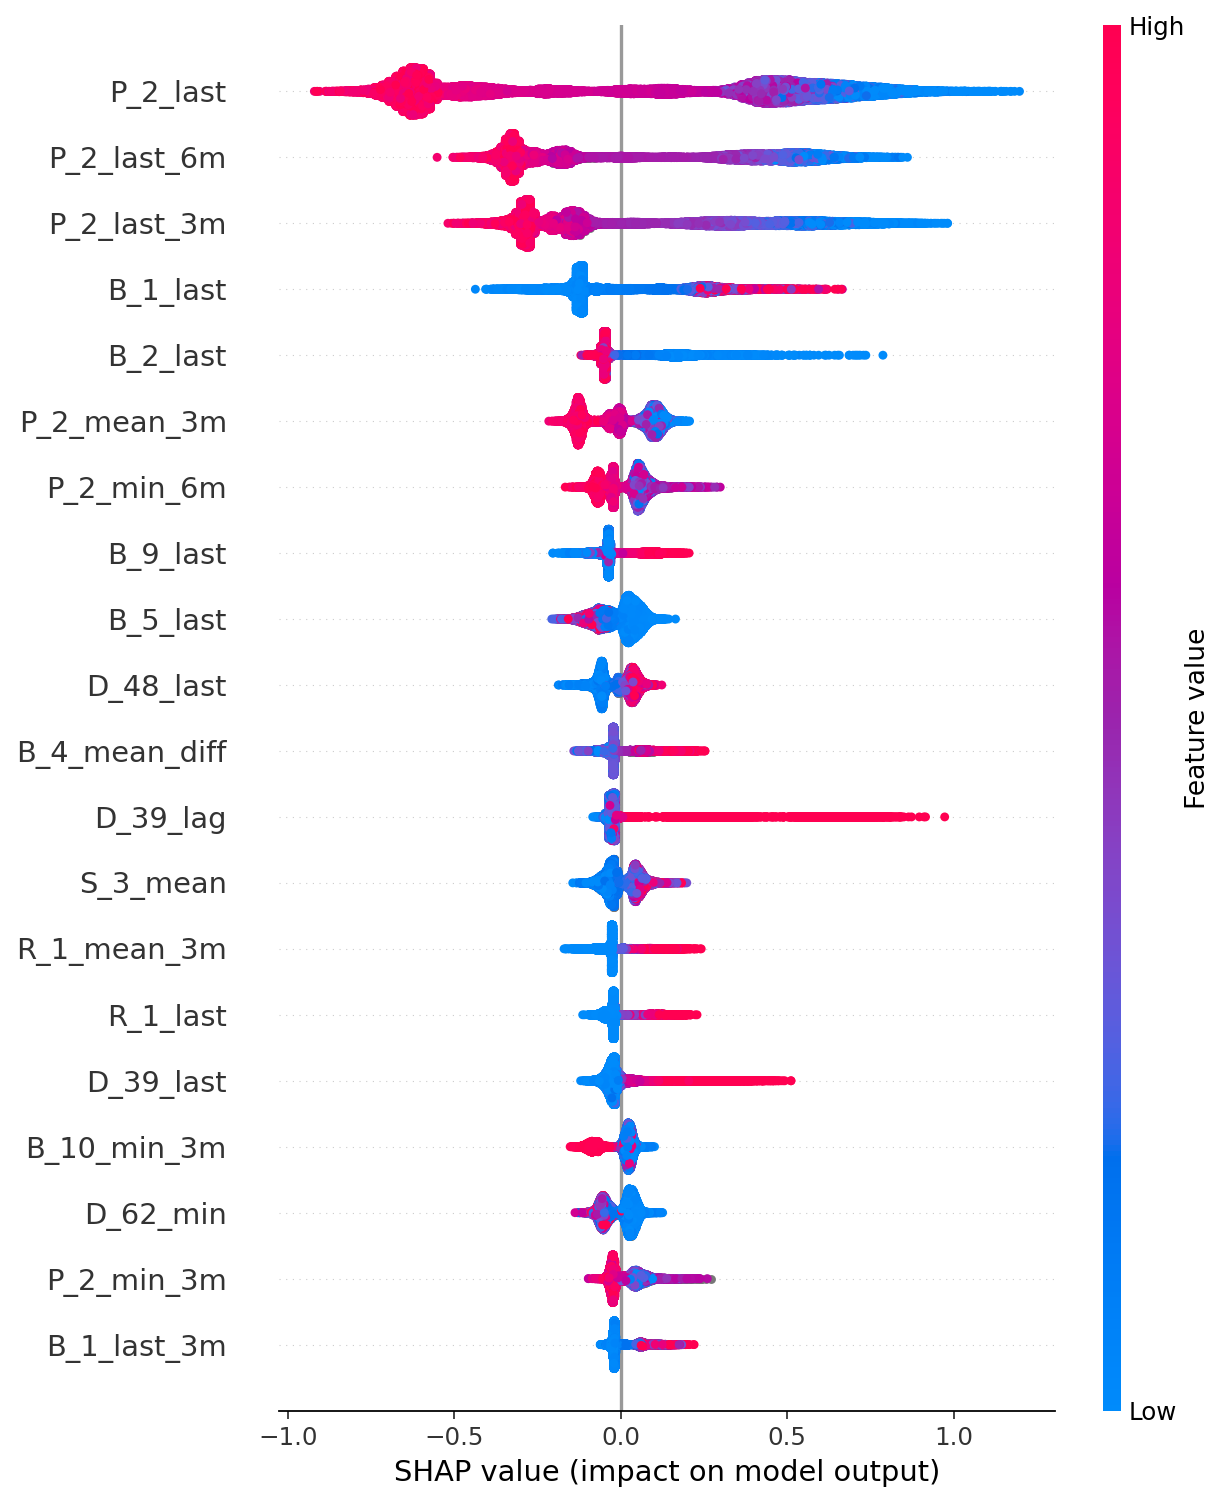

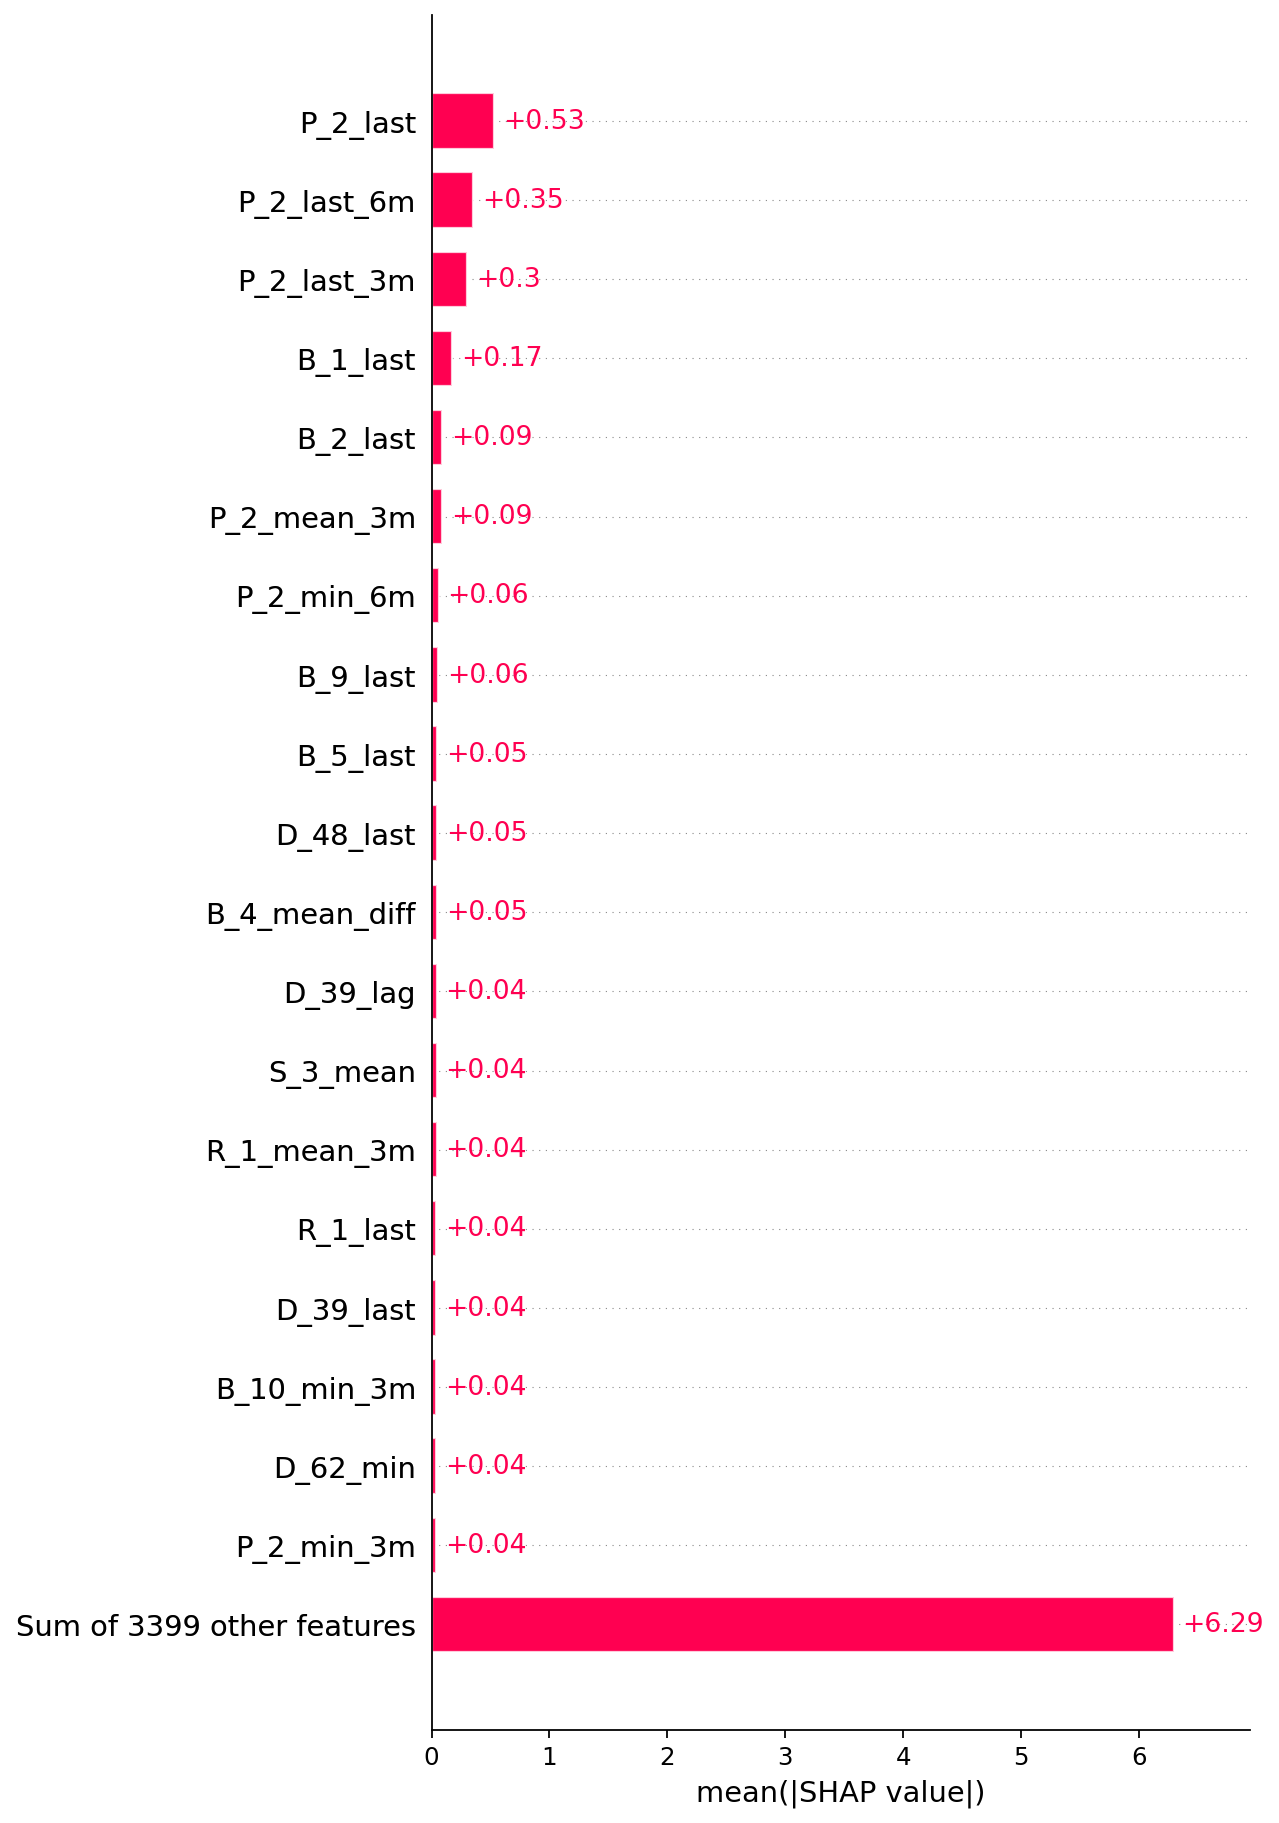

In [21]:
lightgbm_best_fold = best_fold_from_report("lightgbm")
lightgbm_oof = pd.read_parquet(PROJECT_ROOT / "data" / "predictions" / "lightgbm_oof.parquet")
lightgbm_model = lgb.Booster(model_file=str(MODEL_DIR / "lightgbm" / f"lgbm_fold_{lightgbm_best_fold}.txt"))
X_lightgbm = X.iloc[lightgbm_oof.index[lightgbm_oof["fold"] == lightgbm_best_fold]]

save_best_fold_shap_plots(lightgbm_model, X_lightgbm, "lightgbm", PLOTS_DIR)
print(f"Saved LightGBM SHAP plots from fold {lightgbm_best_fold}.")

display(Image(filename=str(PLOTS_DIR / "lightgbm_shap_summary.png")))
display(Image(filename=str(PLOTS_DIR / "lightgbm_shap_bar.png")))

In [25]:
best_fold_indices = xgboost_oof.loc[
    xgboost_oof["fold"] == xgboost_best_fold
].index

X_xgboost = X.loc[best_fold_indices].copy()

for col in X_xgboost.select_dtypes(include="category").columns:
    X_xgboost[col] = X_xgboost[col].cat.codes.astype("int32")

save_best_fold_shap_plots(
    xgboost_model,
    X_xgboost,
    "xgboost",
    PLOTS_DIR
)

Saved XGBoost SHAP plots from fold 3.


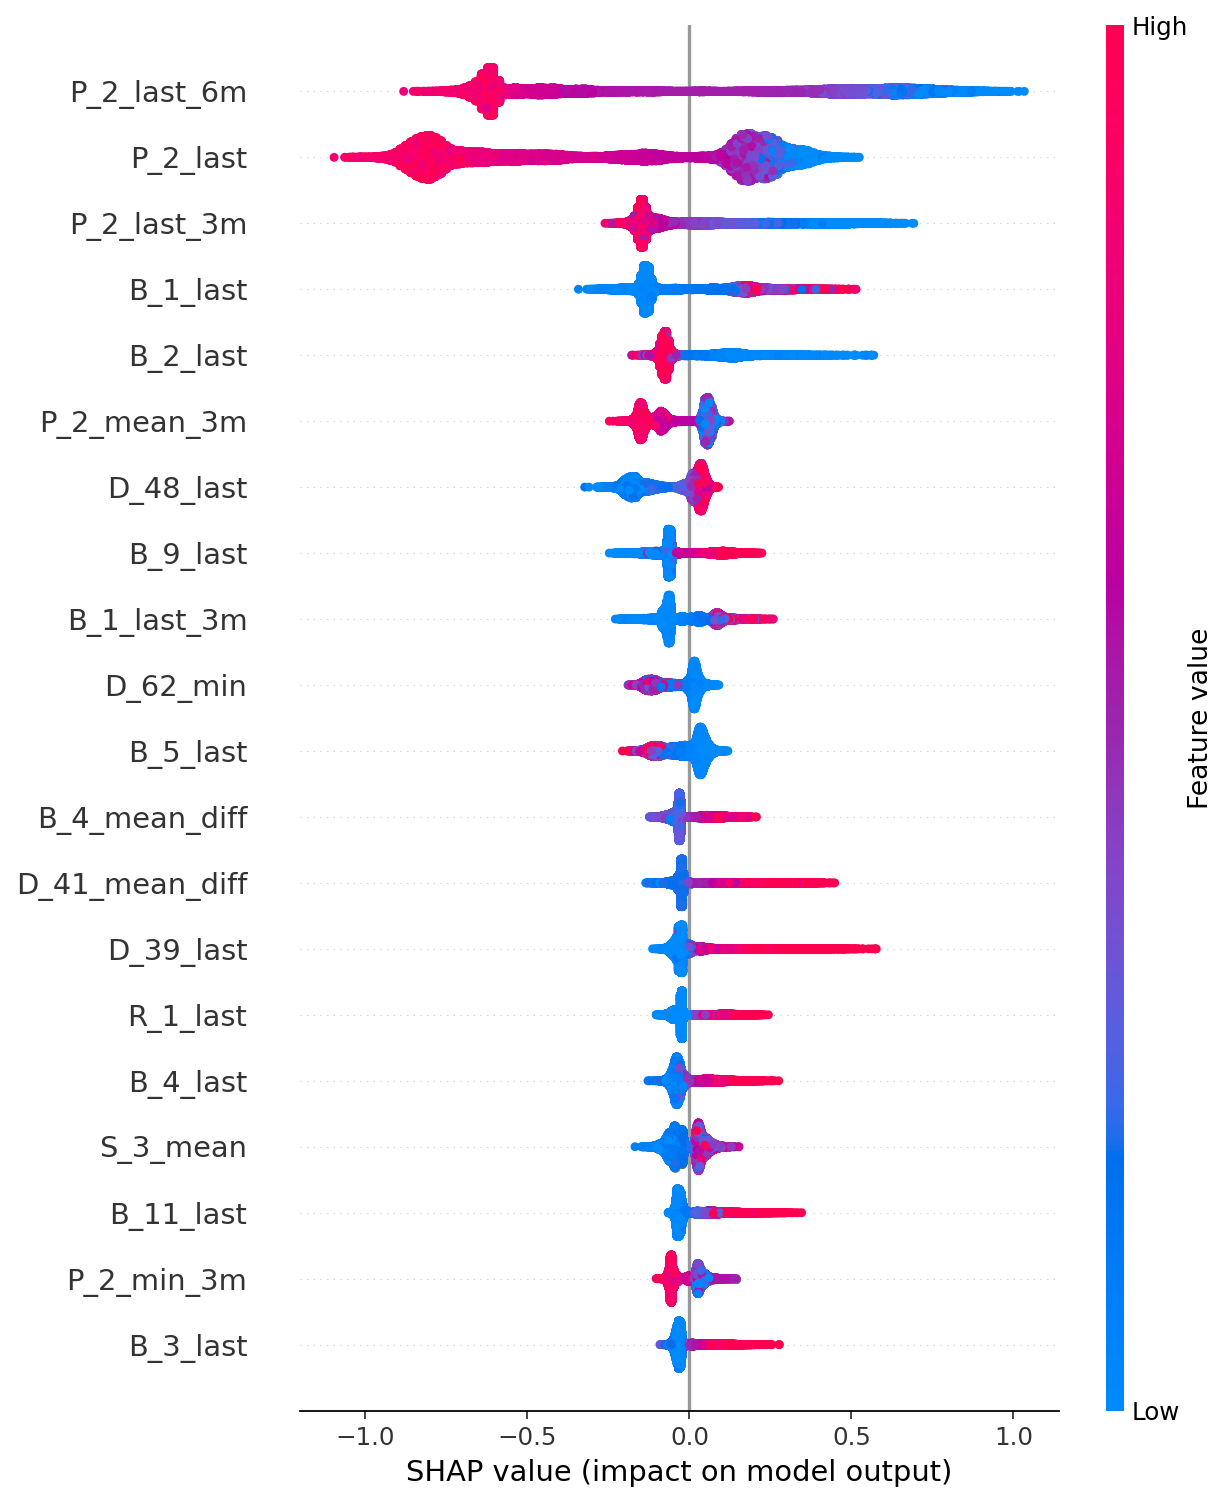

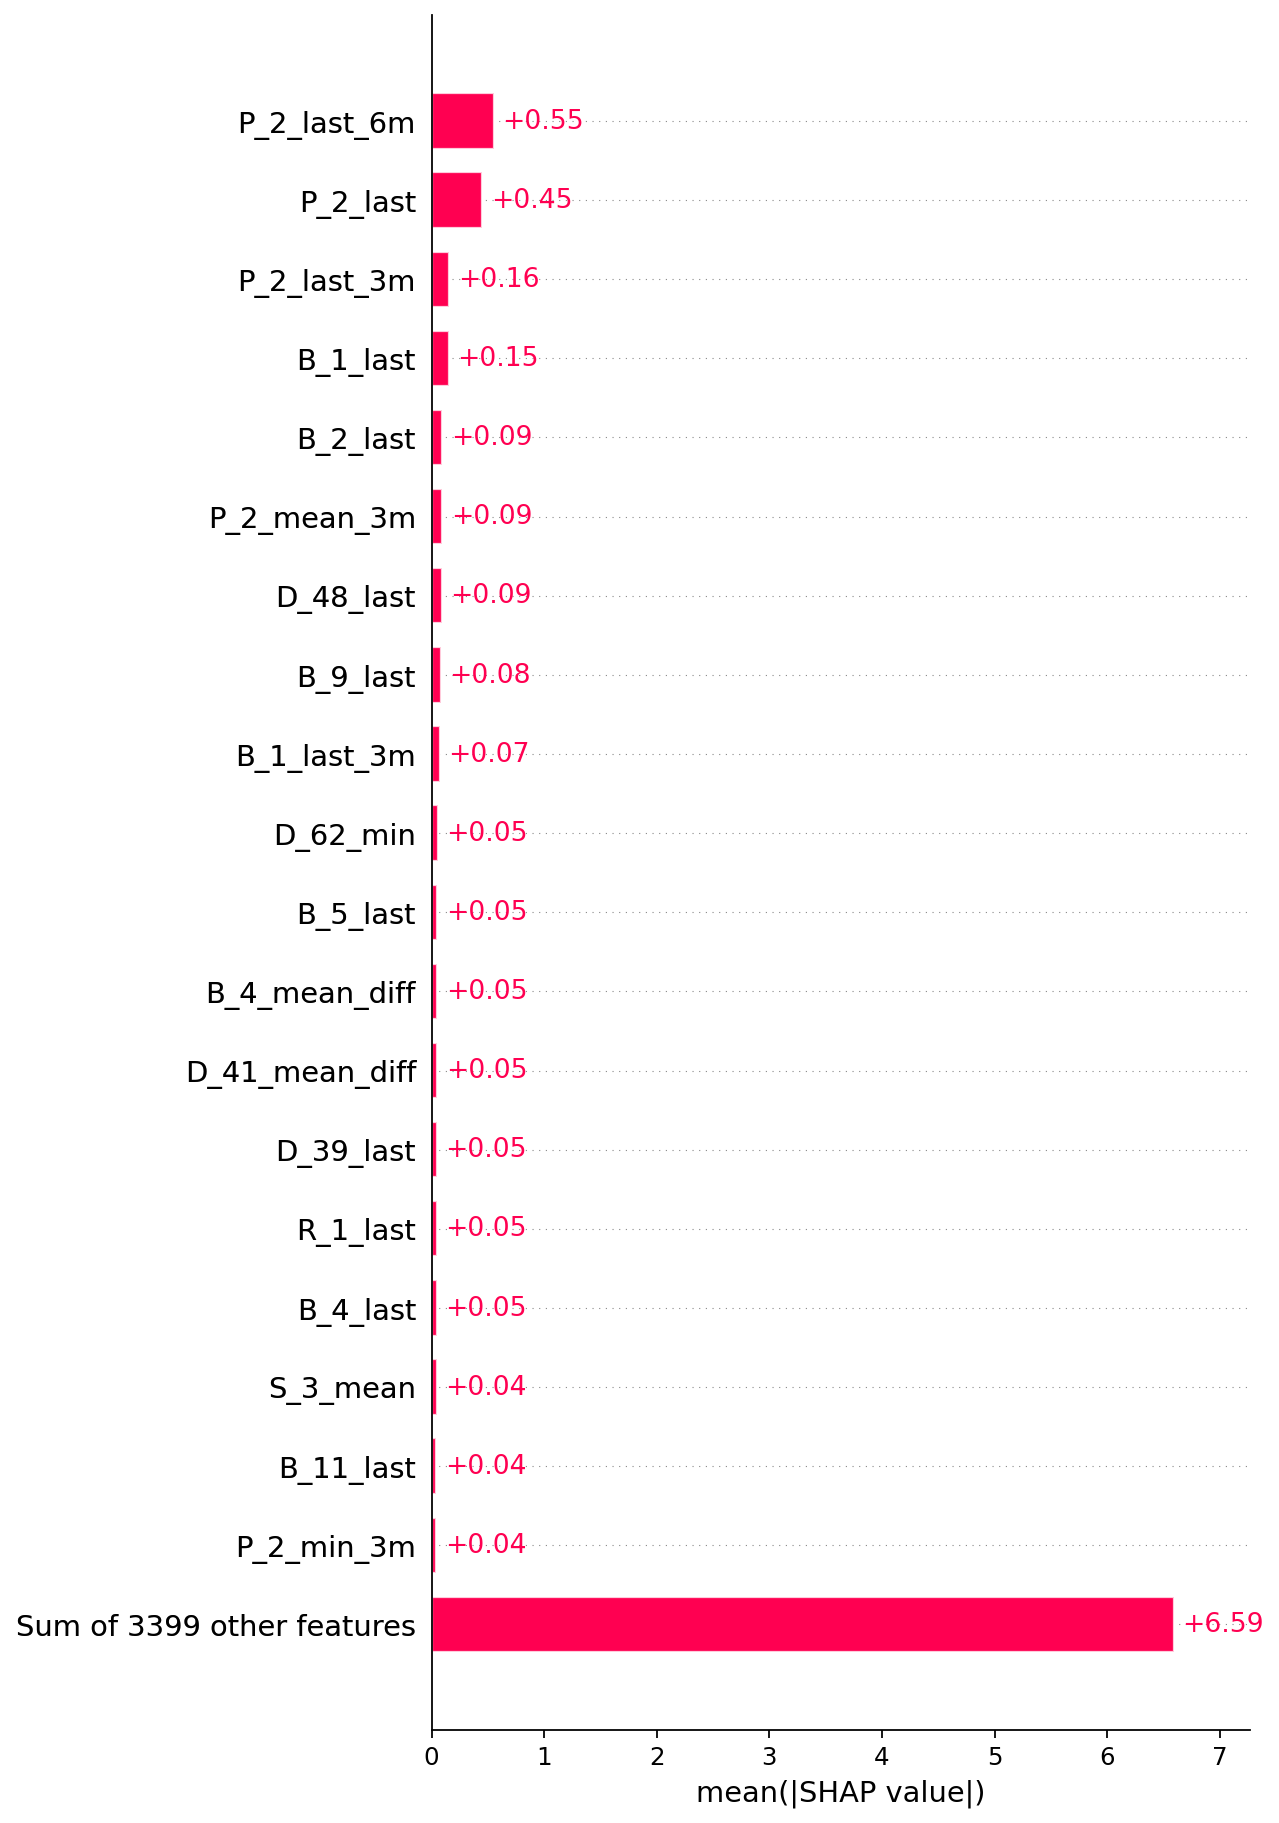

In [26]:
print(f"Saved XGBoost SHAP plots from fold {xgboost_best_fold}.")

display(Image(filename=str(PLOTS_DIR / "xgboost_shap_summary.png")))
display(Image(filename=str(PLOTS_DIR / "xgboost_shap_bar.png")))